Model Comparison Script 

In [1]:
# import necessary libraries 
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split 

import pickle

In [4]:
print(features_all.head())

  Subject Nap Number Triggers_Order_Nap True_Muscle_Activated  \
0  NL04NF          3                  1                  Corr   
1  NL04NF          3                  2                  Corr   
2  NL04NF          3                  3                  Corr   
3  NL04NF          3                  4                  Corr   
4  NL04NF          3                  5                  Zygo   

  Num_Contractions_Zygo Num_Contractions_Corr  \
0                     0                     3   
1                     0                     3   
2                     0                     3   
3                     0                     3   
4                     3                     0   

                                             WL_Zygo  \
0  [18.012655266546297, 18.930453102271112, 19.11...   
1  [23.763915980078355, 23.99348511331316, 24.160...   
2  [26.22725473717977, 26.709581700713645, 27.404...   
3  [20.05133406428719, 22.00059109384234, 22.3608...   
4  [16.285735678622185, 18.3444540

In [12]:
# preparing training/testing data 
#features_all = pd.read_pickle("training_features_11032026.pkl")

X_zygo = features_all[["Zygo"]] 
X_corr = features_all[["Corr" ]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

X = np.concatenate((X_zygo, X_corr), axis=0)
y = np.concatenate([features_all["Num_Contractions_Zygo"].astype(int).to_numpy(),
                    features_all["Num_Contractions_Corr"].astype(int).to_numpy()])       

   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # keep 20% purely for testing 

In [18]:
#results = [] 

models_folder = "models"   # change to your folder path

model_files = sorted(glob.glob(os.path.join(models_folder, "*.pkl")))

for model_file in model_files:
    model_name = os.path.splitext(os.path.basename(model_file))[0]
    
    # skipping unwanted models 
    if (model_name.startswith("M") and model_name[1:].isdigit() and "1" not in model_name) == False:
        continue 

    with open(model_file, "rb") as f:
        model = pickle.load(f)

    print(model_name)
    # predict 
    y_pred_train = model.predict(X_train)  
    y_pred_train = np.argmax(y_pred_train, axis=1)   

    # Predict on test data
    y_pred_test = model.predict(X_test)   
    y_pred_test = np.argmax(y_pred_test, axis=1)   

    # Calculate accuracy
    accuracy_training = accuracy_score(y_train, y_pred_train)   
    accuracy_test = accuracy_score(y_test, y_pred_test)  

    # Calculate F1 score
    f1_training = f1_score(y_train, y_pred_train, average='weighted')  
    f1_test = f1_score(y_test, y_pred_test, average='weighted')  

    # Calculate precision 
    prec_training = precision_score(y_train, y_pred_train, average="weighted", zero_division=0)
    prec_test = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)

    # Calculate recall 
    recall_training = recall_score(y_train, y_pred_train, average="weighted", zero_division=0)
    recall_test = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)


    # plotting confusion matrix 
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # plotting model accuracy 
    # plotting model accuracy 
    plt.plot(model_history.history['accuracy'], label='accuracy')
    plt.plot(model_history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0.8, 1])
    plt.xlim([0,20])
    plt.legend(loc='lower right')
    plt.title("Model 5 Accuracy")
    plt.show()


    ''' 
    results.append({
        "model": model_name,
        "accuracy_train": accuracy_training,
        "accuracy_test": accuracy_test,
        "precision_train": prec_training,
        "precision_test": prec_test,
        "recall_train": recall_training,
        "recall_test": recall_test,
        "f1_train": f1_training, 
        "f1_test": f1_test
    })
    ''' 


#metrics_df = pd.DataFrame(results)

#metrics_df.to_excel("model_comparison_metrics.xlsx", index=False)
#print(metrics_df)

M2
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
M3
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
M4
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
M5
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
M6
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
M7
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
M8
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [19]:
metrics_df = pd.DataFrame(results)

metrics_df.to_excel("model_comparison_metrics.xlsx", index=False)
print(metrics_df)

  model  accuracy_train  accuracy_test  precision_train  precision_test  \
0    M1        0.972581       0.885536         0.972658        0.863604   
1    M2        0.999401       0.936303         0.999285        0.936204   
2    M3        0.991978       0.872126         0.992017        0.852075   
3    M4        0.964320       0.896552         0.963373        0.889579   
4    M5        0.999761       0.934387         0.999641        0.934665   
5    M6        0.999761       0.935345         0.999642        0.935011   
6    M7        0.999761       0.935345         0.999642        0.935011   
7    M8        0.896671       0.863506         0.896330        0.812598   

   recall_train  recall_test  f1_train   f1_test  
0      0.972581     0.885536  0.971458  0.870559  
1      0.999401     0.936303  0.999330  0.930114  
2      0.991978     0.872126  0.991915  0.849567  
3      0.964320     0.896552  0.961984  0.881353  
4      0.999761     0.934387  0.999701  0.928467  
5      0.999761   

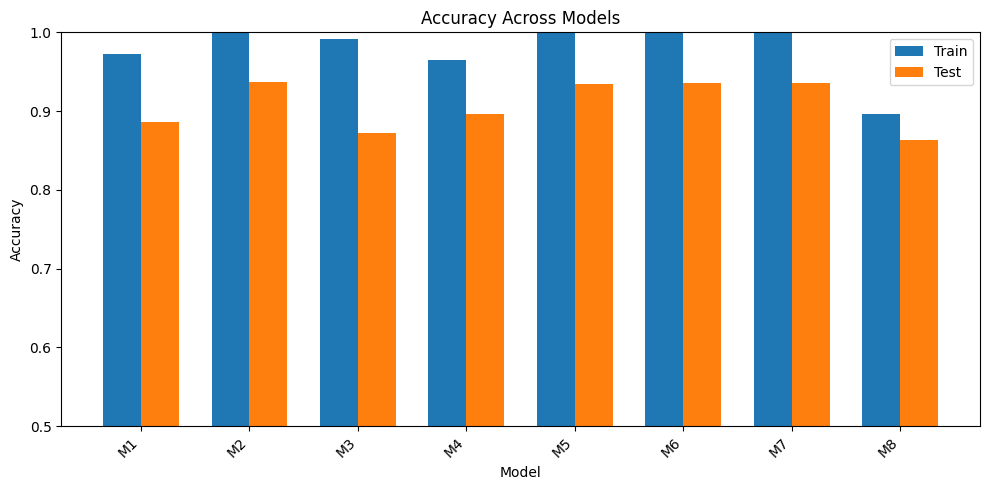

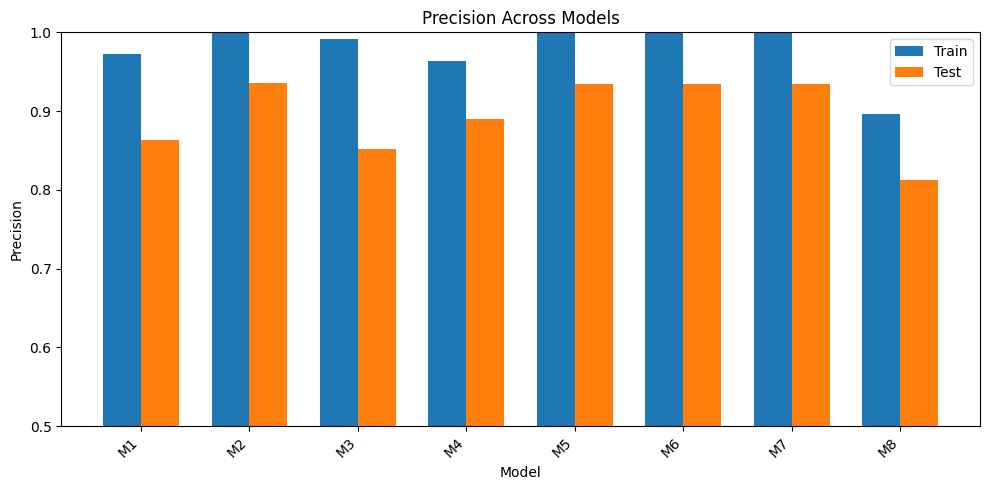

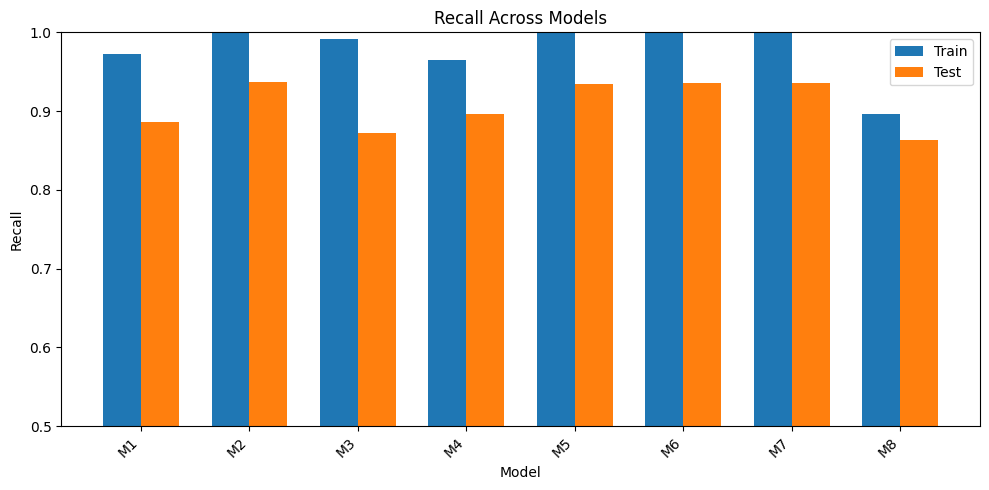

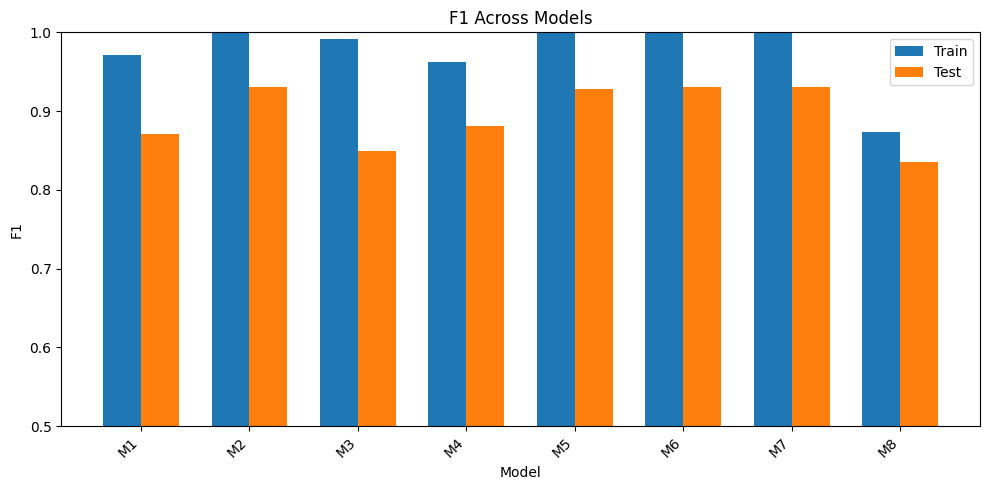

In [26]:
metrics_train = ["accuracy_train", "precision_train", "recall_train", "f1_train"]
metrics_test = ["accuracy_test", "precision_test", "recall_test", "f1_test"]
metrics = ["accuracy", "precision", "recall", "f1"]

for i in range(len(metrics_train)):
    metric_train = metrics_train[i]
    metric_test = metrics_test[i]
    metric = metrics[i]

    plt.figure(figsize=(10, 5))
    x = np.arange(len(metrics_df["model"]))
    width = 0.35


    plt.bar(x - width/2, metrics_df[metric_train], width, label="Train")
    plt.bar(x + width/2, metrics_df[metric_test], width, label="Test")
    
    plt.xlabel("Model")
    plt.ylabel(metric.capitalize())
    plt.title(f"{metric.capitalize()} Across Models")
    plt.xticks(rotation=45, ha="right")
    plt.xticks(x, metrics_df["model"])
    plt.ylim(.5,1)
    plt.legend()
    plt.tight_layout()
    plt.show()